In [5]:
import os
import random
import numpy as np
import torch
import pandas as pd
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from data_processing import load_preprocessed_dataset, get_xy_from_data

In [6]:
# Load the preprocessed dataset
df = load_preprocessed_dataset()
print(df.head())




---- Preprocessed Dataset Info ----
Number of rows: 61000
Number of columns: 39
-----------------------------------
   Timestamp  Activity ID  Heart Rate  Hand Sensor - Temperature  \
0          0            1         100                     30.375   
1          1            1         100                     30.375   
2          2            1         100                     30.375   
3          3            1         100                     30.375   
4          4            1         101                     30.375   

   Hand Sensor - Accelerometer - X  Hand Sensor - Accelerometer - Y  \
0                          2.30106                          7.25857   
1                          2.24615                          7.48180   
2                          2.30000                          7.10681   
3                          2.49455                          7.52335   
4                          2.71654                          8.30596   

   Hand Sensor - Accelerometer - Z  Hand Sensor 


Top 10 features most correlated with 'Age':

Max HR                              1.000000
Resting HR                          0.426678
Height                              0.288871
Ankle Sensor - Temperature          0.176634
Sex - Female                        0.154702
Chest Sensor - Accelerometer - Z    0.131064
Ankle Sensor - Accelerometer - Z    0.111726
Chest Sensor - Temperature          0.109757
Hand Sensor - Magnetometer - X      0.102833
Chest Sensor - Magnetometer - Z     0.096561
Name: Age, dtype: float64 


Top 10 features most correlated with 'Heart Rate':

Chest Sensor - Magnetometer - Z     0.434688
Chest Sensor - Accelerometer - Z    0.433713
Ankle Sensor - Magnetometer - X     0.409080
Chest Sensor - Magnetometer - Y     0.367593
Hand Sensor - Magnetometer - X      0.353925
Hand Sensor - Accelerometer - X     0.338254
Ankle Sensor - Accelerometer - X    0.311776
Ankle Sensor - Accelerometer - Y    0.281218
Ankle Sensor - Magnetometer - Y     0.252415
Activity ID       

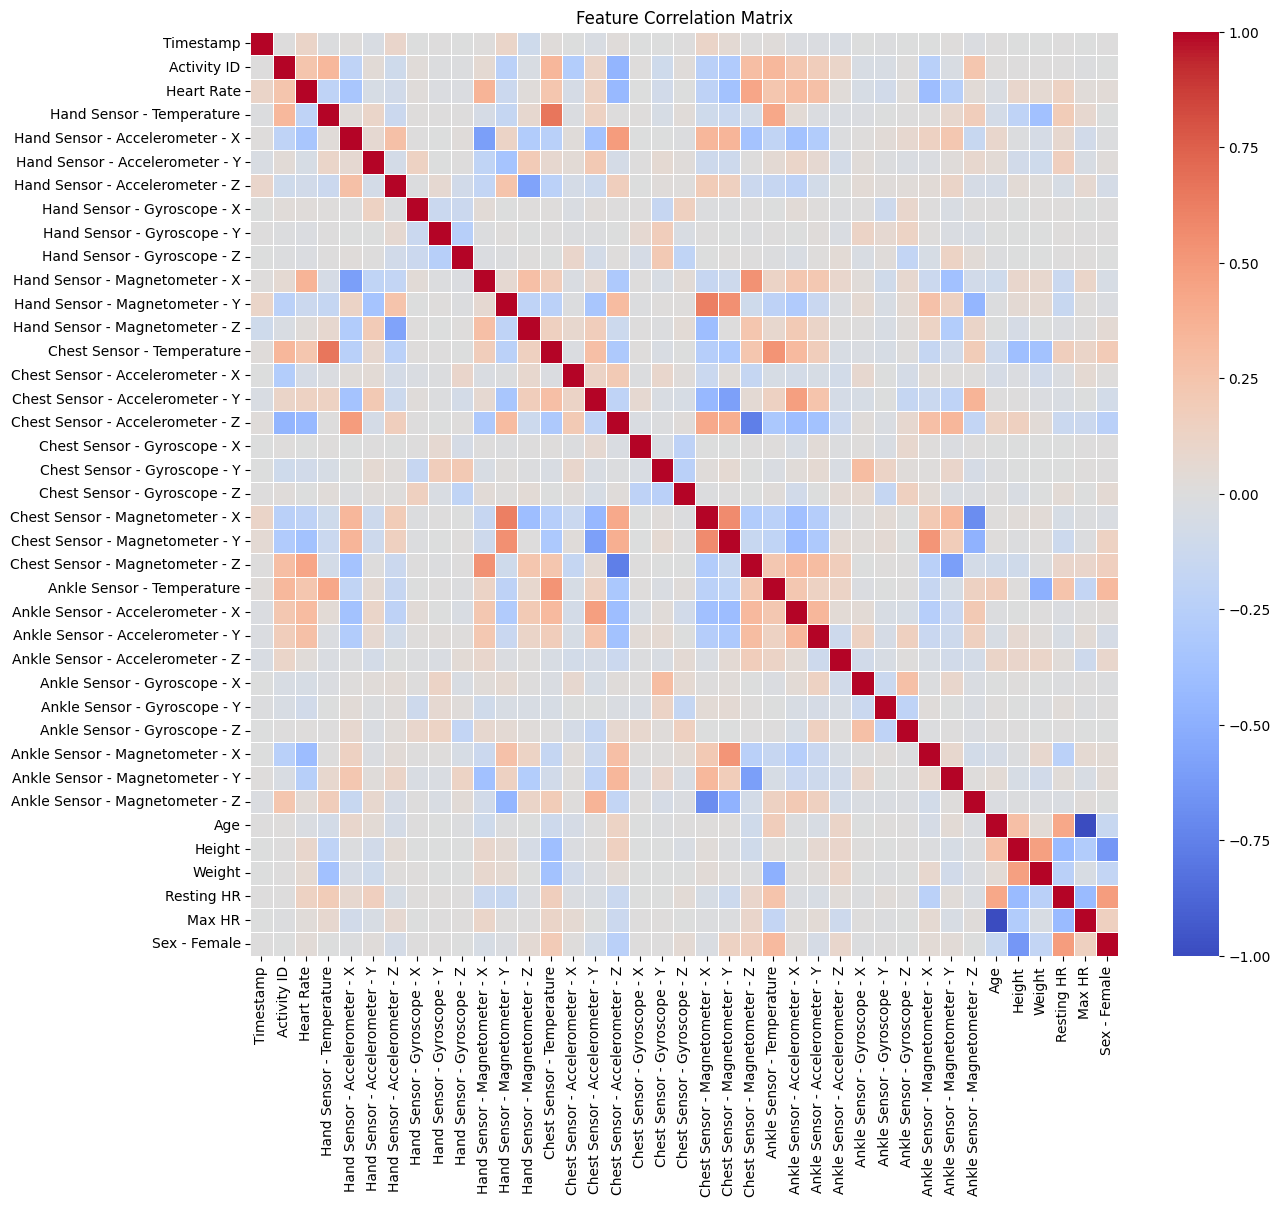

In [7]:
# 2. Compute the full correlation matrix
corr_matrix = df.corr()

# 3. Helper function to pull out top N correlations for a given column
def top_correlations(corr_mat: pd.DataFrame, column: str, n: int = 10) -> pd.Series:
    # Drop self‐correlation, take absolute value, sort descending
    corrs = corr_mat[column].drop(labels=[column])
    return corrs.abs().sort_values(ascending=False).head(n)

# 4. Print top correlations for Age, Heart Rate, and Sex
targets = ['Age', 'Heart Rate', 'Sex - Female']
for col in targets:
    print(f"\nTop 10 features most correlated with '{col}':\n")
    print(top_correlations(corr_matrix, col, n=10), "\n")

# 5. (Optional) Plot a heatmap of the full correlation matrix
plt.figure(figsize=(14, 12))
sns.heatmap(
    corr_matrix,
    cmap='coolwarm',
    center=0,
    linewidths=0.5,
    annot=False  # set True if you want the correlation coefficients shown
)
plt.title("Feature Correlation Matrix")
plt.show()

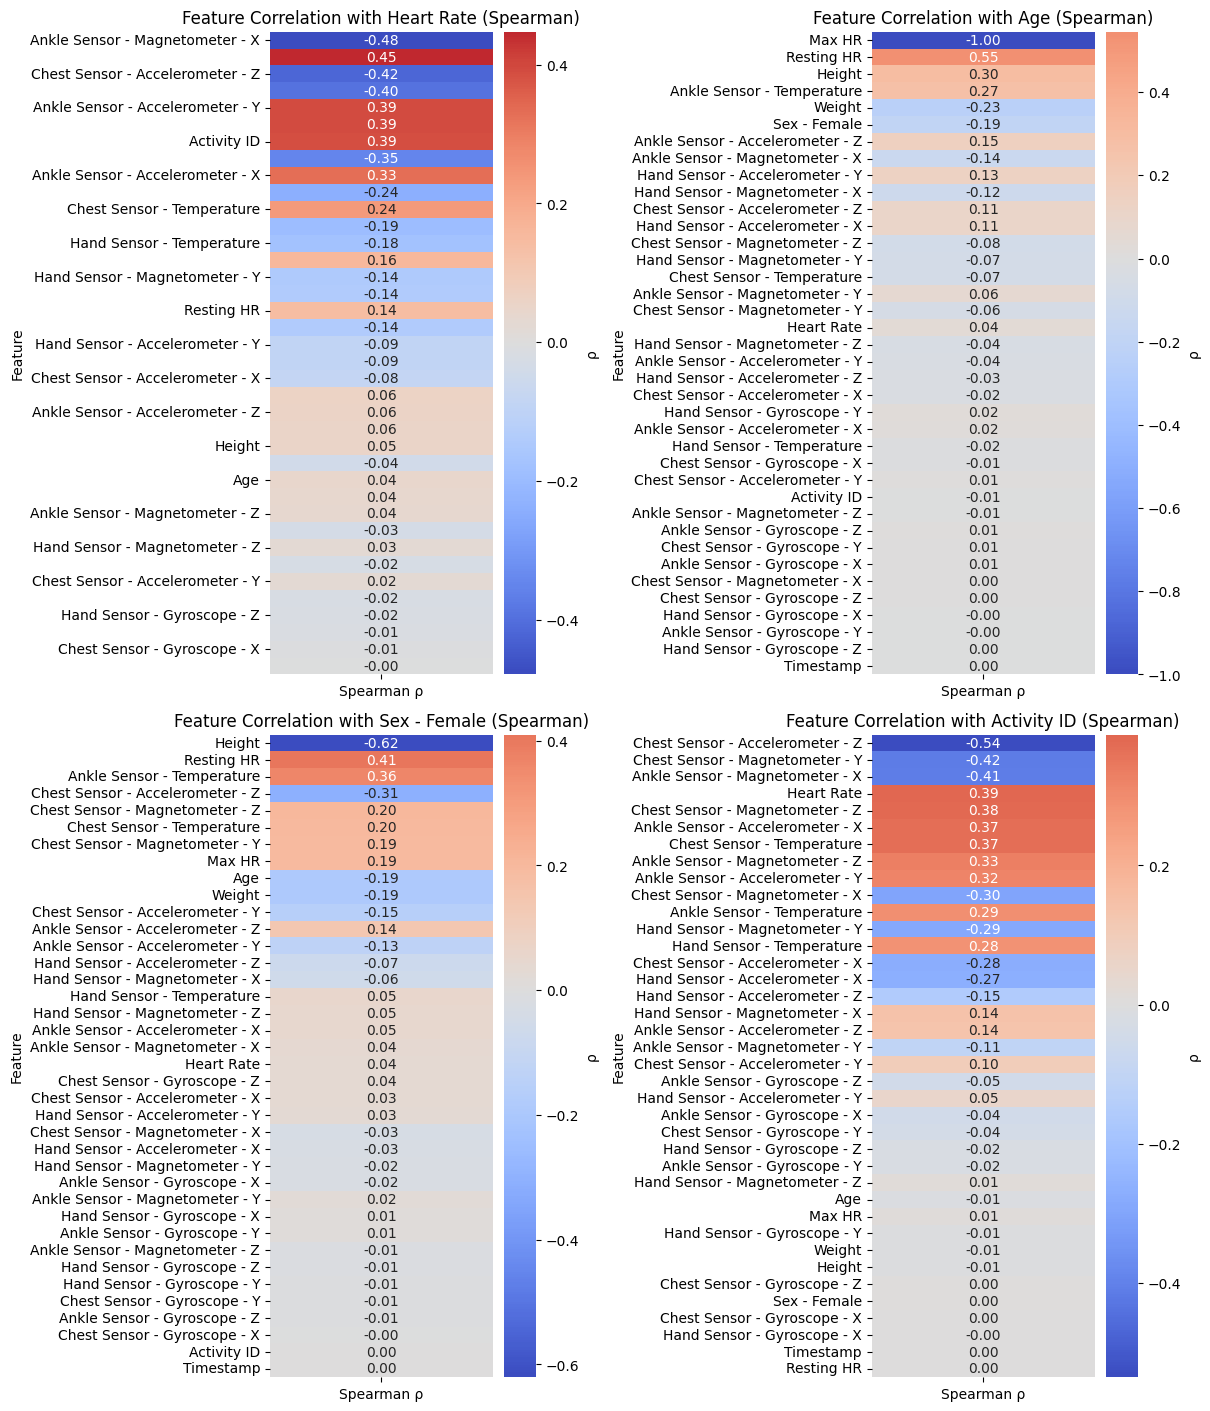

In [12]:

# 2) Compute Spearman correlations
spearman = df.corr(method='spearman')

# 3) Function to get top N features (by absolute rho) for a given target
def top_features_for_target(corr_mat: pd.DataFrame, target: str, top_n: int = 25):
    # drop self, sort by absolute value
    rho = corr_mat[target].drop(labels=[target]).dropna()
    return rho.reindex(rho.abs().sort_values(ascending=False).head(top_n).index)

# 4) Plot a 2×2 grid of heatmaps, one per target
targets = ['Heart Rate', 'Age', 'Sex - Female', 'Activity ID']
n_top   = 40   # how many features to show in each strip

fig, axes = plt.subplots(2, 2, figsize=(12, 14), constrained_layout=True)
axes = axes.flatten()

for ax, tgt in zip(axes, targets):
    top_rhos = top_features_for_target(spearman, tgt, top_n=n_top)
    # build a single-column DataFrame so seaborn.heatmap draws it as a vertical strip
    strip = top_rhos.to_frame(name='Spearman ρ')
    sns.heatmap(
        strip,
        annot=True,
        fmt=".2f",
        cmap='coolwarm',
        center=0,
        cbar_kws={'label': 'ρ'},
        ax=ax
    )
    ax.set_title(f'Feature Correlation with {tgt} (Spearman)')
    ax.set_ylabel('Feature')
    ax.set_xlabel('')

plt.show()


---- Preprocessed Dataset Info ----
Number of rows: 61000
Number of columns: 39
-----------------------------------


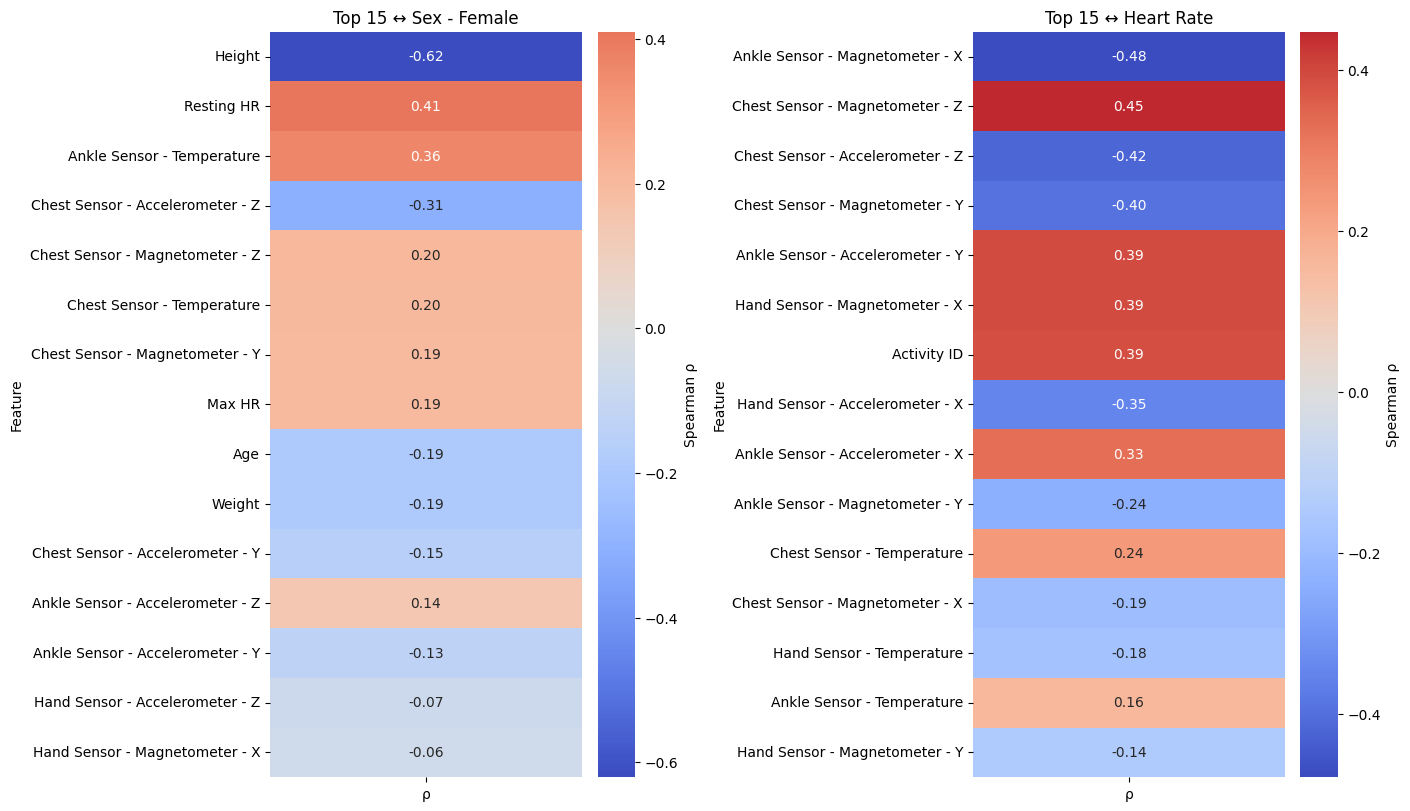

In [13]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1) Load your data
df = load_preprocessed_dataset()

# 2) Compute Spearman correlations
corr = df.corr(method='spearman')

# 3) Helper: pick top features (by absolute ρ) for a given target
def top_corr_features(corr_mat: pd.DataFrame, target: str, top_n: int = 15):
    """Returns a Series of the top_n correlations for `target`, sorted by absolute value."""
    s = corr_mat[target].drop(labels=[target]).dropna()
    top = s.abs().sort_values(ascending=False).head(top_n)
    return s[top.index]  # preserve sign

# 4) Plotting helper
def plot_corr_strip(corr_series: pd.Series, ax: plt.Axes):
    """Given a Series indexed by feature name, plots a 1-column heatmap."""
    df_strip = corr_series.to_frame(name='ρ')
    sns.heatmap(
        df_strip,
        annot=True,
        fmt=".2f",
        cmap='coolwarm',
        center=0,
        cbar_kws={'label': 'Spearman ρ'},
        ax=ax
    )
    ax.set_ylabel('Feature')
    ax.set_xlabel('')
    ax.set_title(f"Top {len(df_strip)} ↔ {corr_series.name}")

# 5) Build figure
targets = ['Sex - Female', 'Heart Rate']
n_top   = 15

fig, axes = plt.subplots(1, 2, figsize=(14, 8), constrained_layout=True)

for ax, tgt in zip(axes, targets):
    series = top_corr_features(corr, tgt, top_n=n_top)
    series.name = tgt
    plot_corr_strip(series, ax)

plt.show()


FEATURES = [
    'Height',
    'Weight',
    'Resting HR',
    'Chest Sensor - Magnetometer - Y',
    'Ankle Sensor - Accelerometer - X',
    'Activity ID',
    'Ankle Sensor - Magnetometer - Z',  # optional 7th
]

TARGETS = ['Sex - Female', 'Heart Rate']

df_model = df[FEATURES + TARGETS].dropna()
